In [1]:
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt

# 1. Load the dataset
data = pd.read_csv("ab_testing.csv")

In [8]:
# Convert Conversion column into numeric values
# If values are 0 and 1 stored as text, this will convert them
data["Conversion"] = pd.to_numeric(data["Conversion"], errors="coerce")

In [9]:
# 2. Display the data
print("A/B Testing Dataset:")
print(data)

A/B Testing Dataset:
      User  Group  Conversion
0     14292     B         NaN
1     11682     A         NaN
2     19825     A         NaN
3     16080     B         NaN
4     18851     A         NaN
...     ...   ...         ...
4995  16360     B         NaN
4996  18084     B         NaN
4997  12063     A         NaN
4998  18647     B         NaN
4999  16686     A         NaN

[5000 rows x 3 columns]


In [10]:
# Check for missing values
data = data.dropna(subset=["Conversion"])

In [11]:
# 3. Calculate conversion rate for Group A
group_A = data[data["Group"] == "A"]

users_A = len(group_A)
conversions_A = group_A["Conversion"].sum()

rate_A = conversions_A / users_A

print("\nGroup A Conversion Rate:", rate_A)
print("Group A Conversion Rate:", rate_A * 100, "%")



Group A Conversion Rate: nan
Group A Conversion Rate: nan %


C:\Users\itlab\AppData\Local\Temp\ipykernel_7468\348748729.py:7: RuntimeWarning: invalid value encountered in scalar divide
  rate_A = conversions_A / users_A


In [12]:
# 4. Calculate conversion rate for Group B
group_B = data[data["Group"] == "B"]

users_B = len(group_B)
conversions_B = group_B["Conversion"].sum()

rate_B = conversions_B / users_B

print("\nGroup B Conversion Rate:", rate_B)
print("Group B Conversion Rate:", rate_B * 100, "%")



Group B Conversion Rate: nan
Group B Conversion Rate: nan %


C:\Users\itlab\AppData\Local\Temp\ipykernel_7468\2342391867.py:7: RuntimeWarning: invalid value encountered in scalar divide
  rate_B = conversions_B / users_B


In [13]:
# 5. Compare conversion rates
print("\nComparison:")
print("Group A:", rate_A * 100, "%")
print("Group B:", rate_B * 100, "%")

if rate_A > rate_B:
    print("Group A has a higher conversion rate.")
elif rate_B > rate_A:
    print("Group B has a higher conversion rate.")
else:
    print("Both groups have the same conversion rate.")


Comparison:
Group A: nan %
Group B: nan %
Both groups have the same conversion rate.


In [14]:
# 6. Null Hypothesis
print("\nH0: pA = pB")


H0: pA = pB


In [15]:
# 7. Alternative Hypothesis
print("H1: pA != pB")

H1: pA != pB


In [16]:
# 8. Significance level
alpha = 0.05
print("Significance Level:", alpha)

Significance Level: 0.05


In [17]:
# 9. Perform two-proportion test
conversions = [conversions_A, conversions_B]
users = [users_A, users_B]

z_stat, p_value = proportions_ztest(conversions, users)


c:\Users\itlab\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\stats\proportion.py:1004: RuntimeWarning: invalid value encountered in divide
  prop = count * 1. / nobs
c:\Users\itlab\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\stats\proportion.py:1018: RuntimeWarning: invalid value encountered in scalar divide
  p_pooled = np.sum(count) * 1. / np.sum(nobs)
c:\Users\itlab\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\stats\proportion.py:1020: RuntimeWarning: divide by zero encountered in divide
  nobs_fact = np.sum(1. / nobs)


In [18]:
# 10. Calculate and display p-value
print("\nZ-statistic:", z_stat)
print("P-value:", p_value)



Z-statistic: nan
P-value: nan


In [19]:
# 11. Compare p-value with 0.05
print("\nComparison of p-value with 0.05:")

if p_value < alpha:
    print("p-value < 0.05")
else:
    print("p-value >= 0.05")



Comparison of p-value with 0.05:
p-value >= 0.05


In [20]:
# 12. Decision
if p_value < alpha:
    print("Decision: Reject the Null Hypothesis (H0)")
else:
    print("Decision: Do not reject the Null Hypothesis (H0)")


Decision: Do not reject the Null Hypothesis (H0)


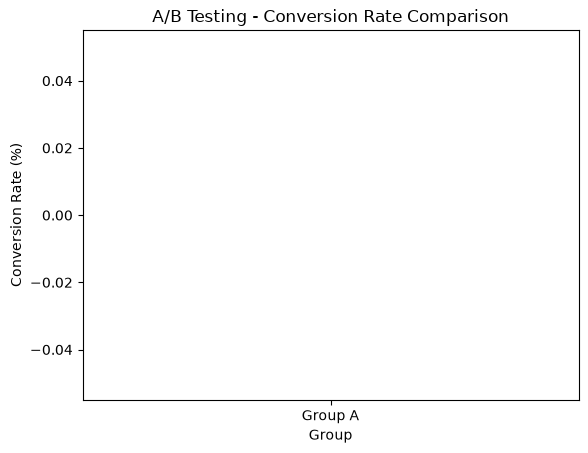

In [22]:
# 13. Create bar chart
groups = ["Group A", "Group B"]
conversion_rates = [rate_A * 100, rate_B * 100]

plt.bar(groups, conversion_rates)

plt.xlabel("Group")
plt.ylabel("Conversion Rate (%)")
plt.title("A/B Testing - Conversion Rate Comparison")
# Display values on bars
for i, rate in enumerate(conversion_rates):
    plt.text(i, rate, f"{rate:.2f}%", ha="center", va="bottom")

plt.show()
